In [3]:
import matplotlib.pyplot as plt
import numpy as np
import SimpleITK as sitk

In [121]:
path_scan = "/home/alceballosa/workspace/medical/data/aneurysm/internal_train/crop_0.4/Tr0001.nii.gz"
path_vessel = "/home/alceballosa/workspace/medical/data/aneurysm/internal_train/crop_0.4_vessel/Tr0001.nii.gz"
path_vessel_edt = "/home/alceballosa/workspace/medical/data/aneurysm/internal_train/crop_0.4_vessel_edt_comp/Tr0001.nii.gz"
scan_header = sitk.ReadImage(path_scan)
scan = sitk.GetArrayFromImage(scan_header)
vessel_header = sitk.ReadImage(path_vessel)
vessel = sitk.GetArrayFromImage(vessel_header)
vessel = (vessel > 0).astype(int)
edt_header = sitk.ReadImage(path_vessel_edt)
edt = sitk.GetArrayFromImage(edt_header)


sz = 64
sz_mask = 8
scan = scan[50 : 50 + sz, 150 : 150 + sz, 200 : 200 + sz]
edt = edt[50 : 50 + sz, 150 : 150 + sz, 200 : 200 + sz]
mask = np.zeros_like(scan)
# randomly turn off  subvolumes of size 2x2x2

for i in range(0, sz, sz_mask):
    for j in range(0, sz, sz_mask):
        for k in range(0, sz, sz_mask):
            if np.random.rand() < 0.75:
                mask[i : i + sz_mask, j : j + sz_mask, k : k + sz_mask] = 1


scan = scan - scan.min()
scan = scan / scan.max()

edt = edt - edt.min()
edt = edt / edt.max()

scan.min(), scan.max()

# apply contrast enhancement

# scan = np.power(scan, 0.5)
scan = np.power(scan, 0.9)

scan_orig = scan.copy()
edt_orig = edt.copy()
scan = np.ma.masked_where(mask == 1, scan)
edt = np.ma.masked_where(mask == 1, edt)

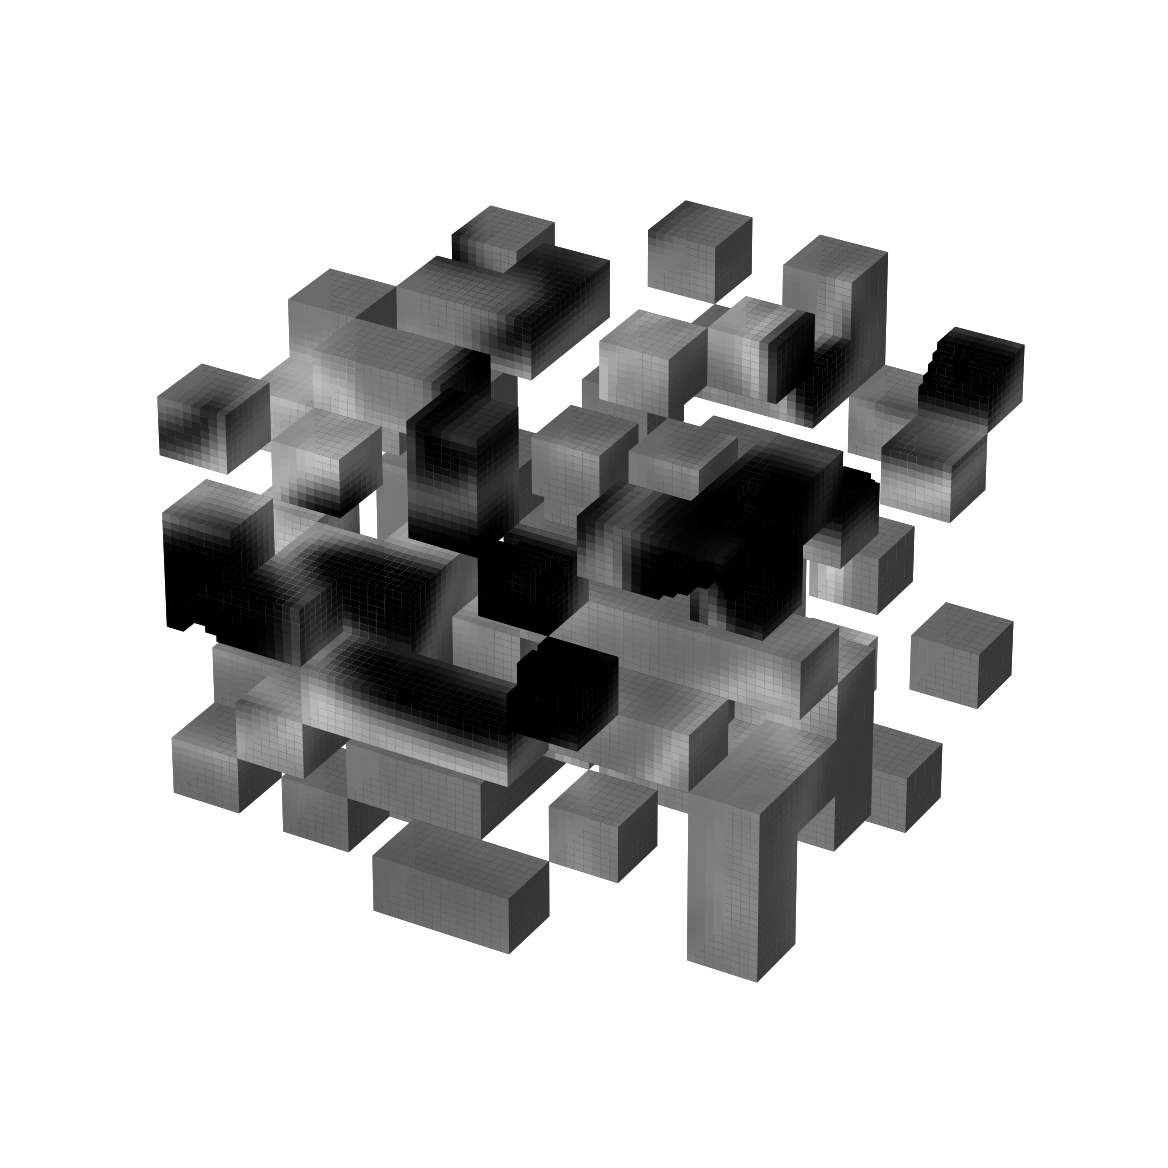

In [ ]:
# plot the data as 3d voxels
# apply mask as transparency
plt.style.use('classic')
fig = plt.figure(dpi=300)
ax = fig.add_subplot(111, projection="3d")


# plot voxels
# ax.voxels(scan, cmap="gray")
# plot voxels and set colors based on the scan values
ax.voxels(scan, facecolors=plt.cm.gray(scan))

# add inferior and superior axes
# remove numbers
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
# remove background
ax.set_facecolor("white")
# no edges
# ax.voxels(mask, edgecolor="r", alpha=0.5)
# save fig as pdf

plt.savefig("scan.png", transparent=True)


plt.show()

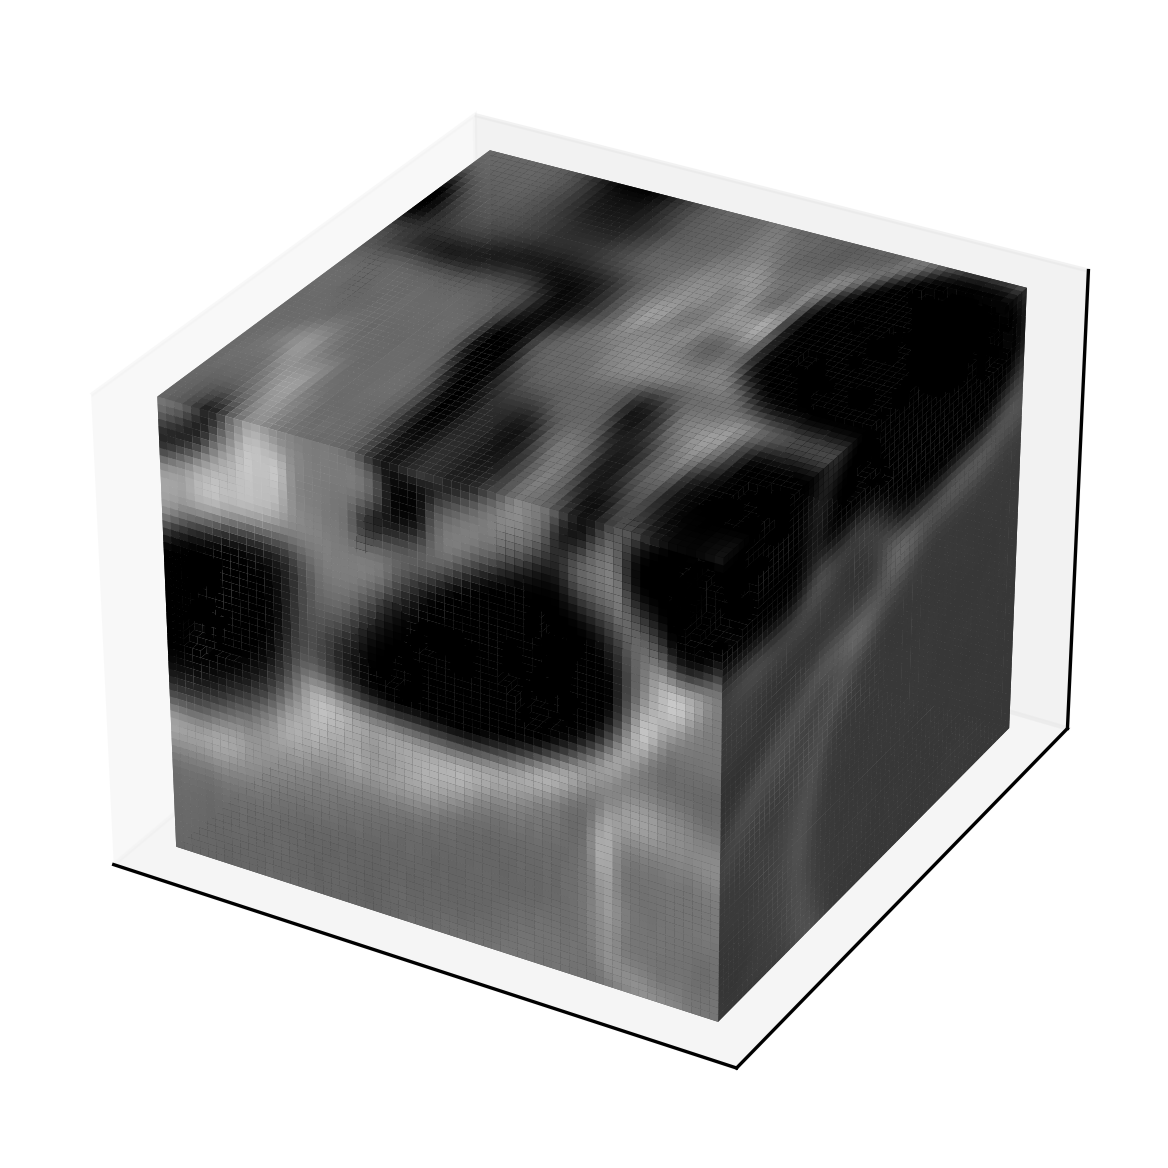

In [124]:
# plot the data as 3d voxels
# apply mask as transparency
fig = plt.figure(dpi=300)
ax = fig.add_subplot(111, projection="3d")


# plot voxels
# ax.voxels(scan, cmap="gray")
# plot voxels and set colors based on the scan values
ax.voxels(scan_orig, facecolors=plt.cm.gray(scan_orig))
# remove numbers
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
# remove background
ax.set_facecolor("white")
# no edges
# ax.voxels(mask, edgecolor="r", alpha=0.5)
# save fig as pdf

plt.savefig("scan_full.png")


plt.show()

In [127]:
edt = np.power(edt, 0.9)

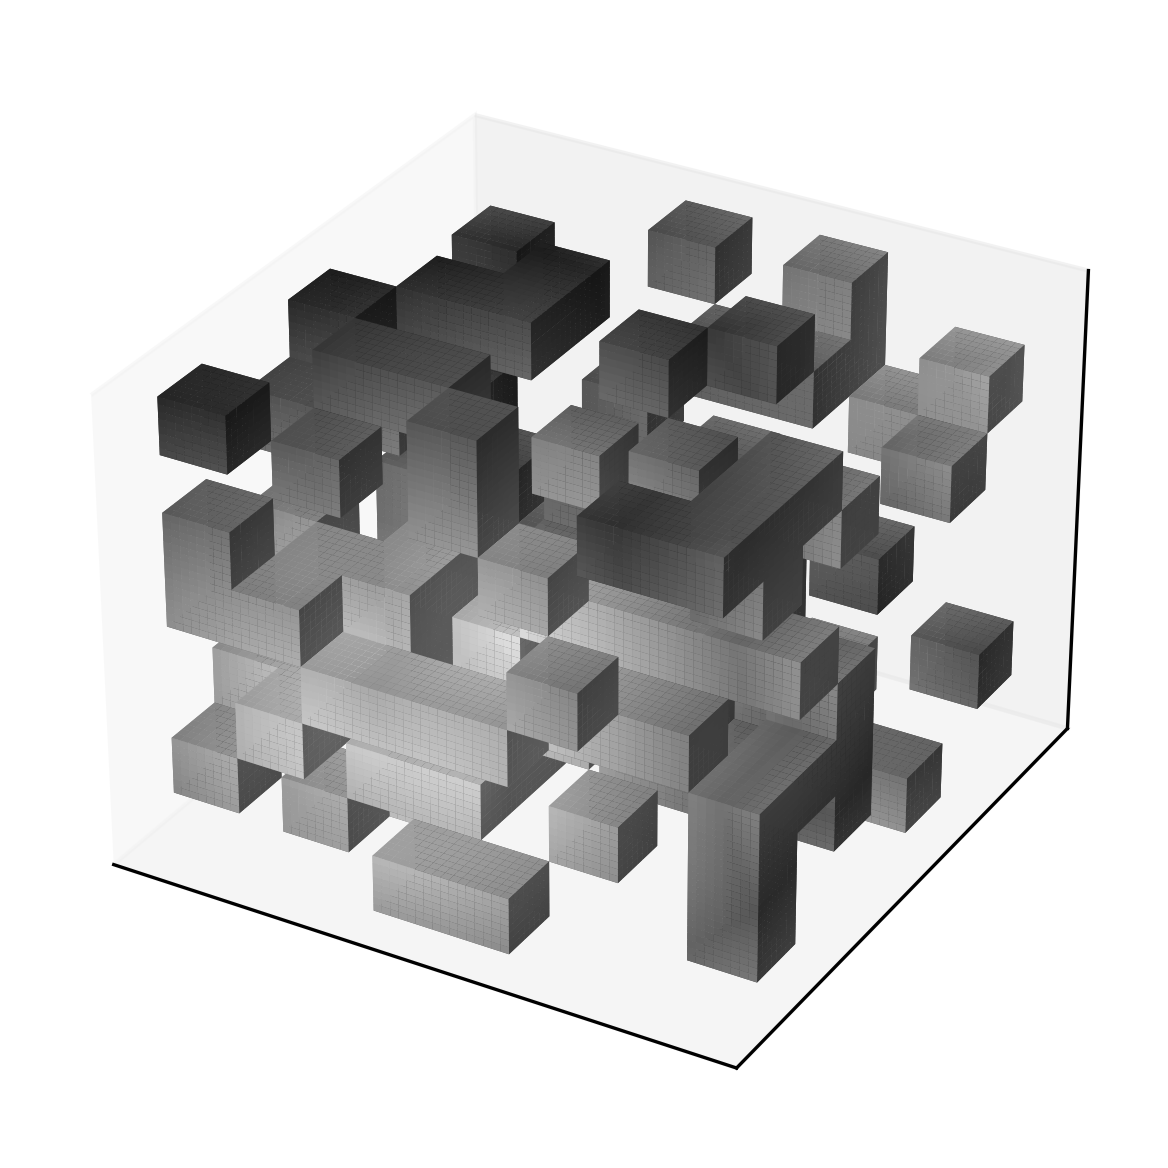

In [128]:
# plot the data as 3d voxels
# apply mask as transparency
fig = plt.figure(dpi=300)
ax = fig.add_subplot(111, projection="3d")


# plot voxels
# ax.voxels(scan, cmap="gray")
# plot voxels and set colors based on the scan values
ax.voxels(edt, facecolors=plt.cm.gray(edt))
# remove numbers
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
# remove background
ax.set_facecolor("white")
# no edges
# ax.voxels(mask, edgecolor="r", alpha=0.5)
# save fig as pdf

plt.savefig("edt_masked.png")


plt.show()

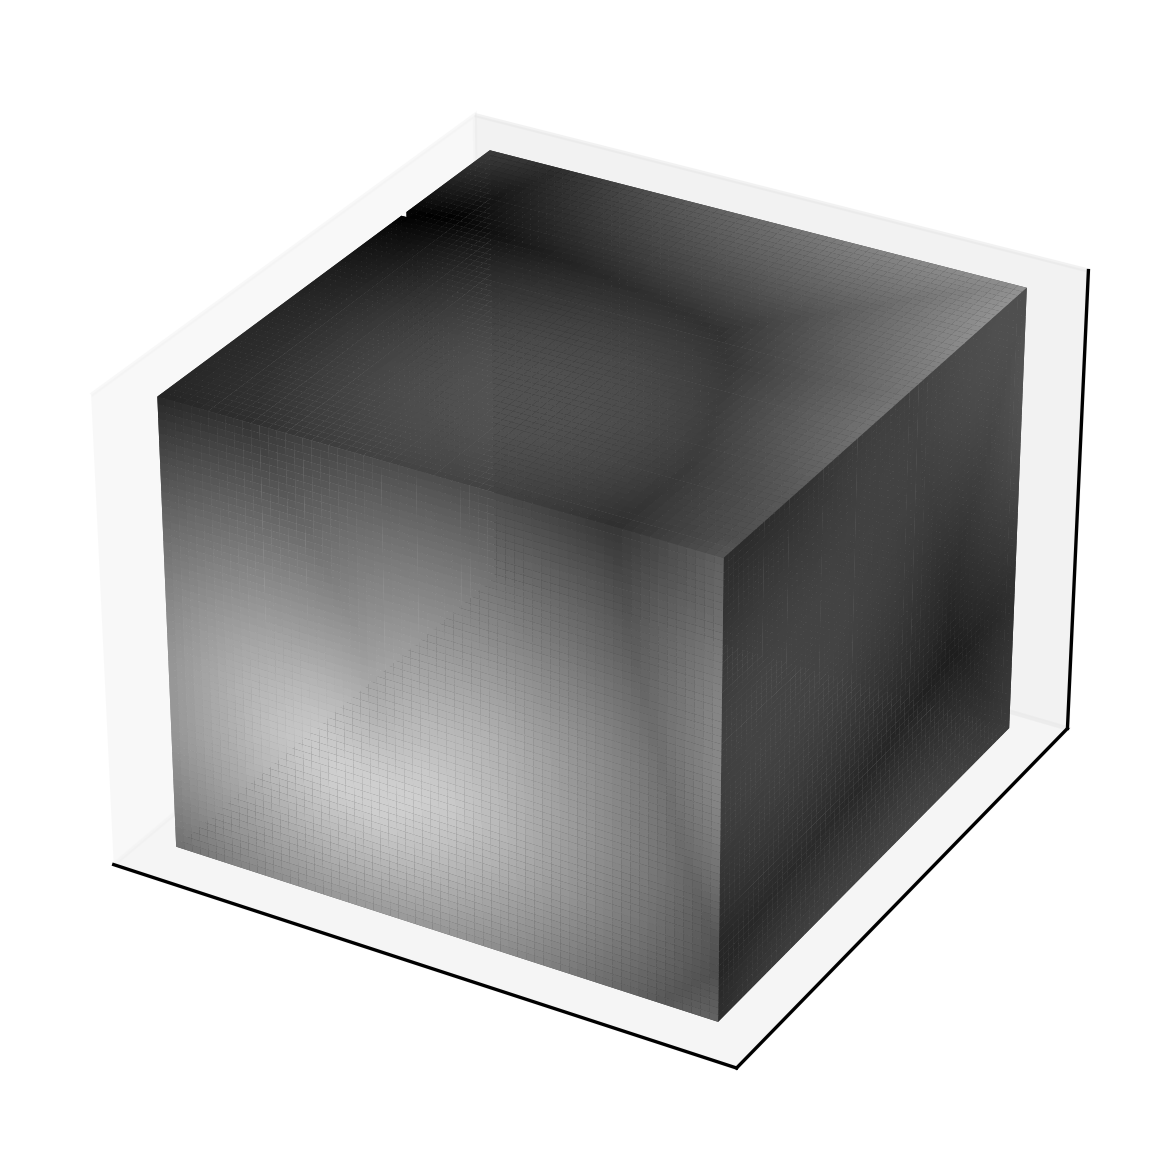

In [129]:
# plot the data as 3d voxels
# apply mask as transparency
fig = plt.figure(dpi=300)
ax = fig.add_subplot(111, projection="3d")


# plot voxels
# ax.voxels(scan, cmap="gray")
# plot voxels and set colors based on the scan values
edt_orig = np.power(edt_orig, 0.9)
ax.voxels(edt_orig, facecolors=plt.cm.gray(edt_orig))
# remove numbers
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])
# remove background
ax.set_facecolor("white")
# no edges
# ax.voxels(mask, edgecolor="r", alpha=0.5)
# save fig as pdf

plt.savefig("edt_full.png")


plt.show()

0.0 0.8252858958068615


AttributeError: 'numpy.ndarray' object has no attribute 'imshow'

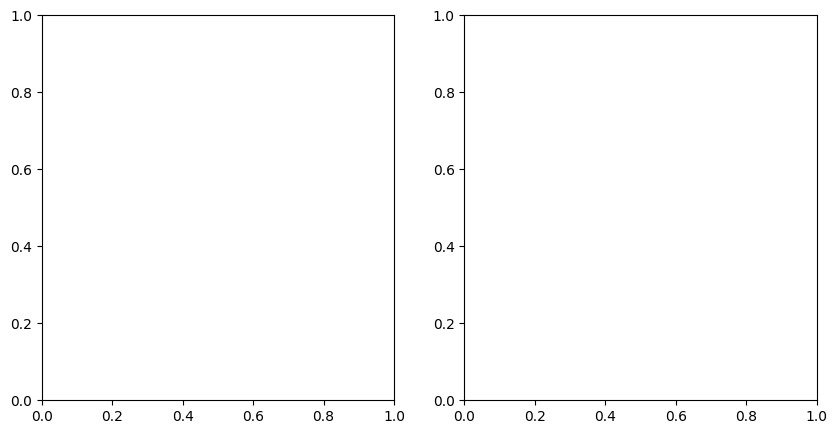

In [83]:
path_scan = "/home/alceballosa/workspace/medical/data/aneurysm/internal_train/crop_0.4/Tr0001.nii.gz"
path_vessel = "/home/alceballosa/workspace/medical/data/aneurysm/internal_train/crop_0.4_vessel/Tr0001.nii.gz"

scan_header = sitk.ReadImage(path_scan)
scan = sitk.GetArrayFromImage(scan_header)
vessel_header = sitk.ReadImage(path_vessel)
vessel = sitk.GetArrayFromImage(vessel_header)
vessel = (vessel > 0).astype(int)

import random


def plot_slices(scan, vessel, range_x, range_y, slice_num):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    scan = scan[
        slice_num,
        range_x[0] : range_x[1],
        range_y[0] : range_y[1],
    ]
    vessel = vessel[
        slice_num,
        range_x[0] : range_x[1],
        range_y[0] : range_y[1],
    ]

    # overlay a 2d grid on top of the scan with each square being 4x4
    scan = scan / scan.max()
    vessel = vessel / vessel.max()
    scan = np.clip(scan, -1, 1)
    vessel = np.clip(vessel, -1, 1)
    # turn vessel into color image
    vessel_viz = np.zeros((vessel.shape[0], vessel.shape[1], 3))
    # vessel_viz[:, :, 0] = vessel
    vessel_viz[:, :, 1] = vessel
    vessel_viz[:, :, 2] = vessel

    # fill 75% of the scan with 1s following the grid
    #

    for i in range(0, scan.shape[0], 16):
        for j in range(0, scan.shape[1], 16):
            rand = random.random()
            if rand < 0.25 or (
                np.sum(vessel[i : i + 16, j : j + 16]) > 0 and rand < 0.8
            ):
                scan[i : i + 16, j : j + 16] = 1
                # draw an x in the middle of the square
                # for t in range(16):
                #    scan[i + t, j + t] = 0
                #    scan[i + t, j + 15 - t] = 0

                # paint red square in the middle of selected area:
                # vessel_viz[i + 7 : i + 9, j + 7 : j + 9, 0] = 1
                # vessel_viz[i + 7 : i + 9, j + 7 : j + 9, 1] = 0
                # vessel_viz[i + 7 : i + 9, j + 7 : j + 9, 2] = 0

    scan_viz = np.zeros((scan.shape[0], scan.shape[1], 3))
    scan_viz[:, :, 0] = scan
    scan_viz[:, :, 1] = scan
    scan_viz[:, :, 2] = scan

    # overlay vessel as a red transparency ovver the scan
    # save the scan image

    scan_save = (scan_viz - np.min(scan_viz)) / 2
    print(np.min(scan_save), np.max(scan_save))

    scan_save = scan_save * 0.66 + vessel_viz * 0.34
    scan = scan_save
    for i in range(0, scan.shape[0], 16):
        scan[i, :] = 0
    for i in range(0, scan.shape[1], 16):
        scan[:, i] = 0
    scan[:, -1] = 0
    scan[-1, :] = 0

    # resize scan to 512,512

    # import scipy

    # scan = scipy.ndimage.zoom(scan, (1024 / scan.shape[0], 1024 / scan.shape[1], 1))

    plt.imsave("scan.png", scan)
    ax.imshow(scan_viz)
    ax.imshow(vessel_viz, alpha=0.25)

    # ax[0].imshow(scan, cmap="gray")
    # ax[0].set_title("Scan")
    # ax[1].imshow(vessel_viz)
    # ax[1].set_title("Vessel")
    # plt.show()
    # save img
    plt.savefig(f"slice_{slice_num}.png")
    plt.show()


range_x = (150, 214 + 64)
range_y = (200, 264 + 64)

plot_slices(scan, vessel, range_y, range_x, 50)